# Transitions

In [1]:
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt


## ■ stimulated emission / spontaneous emission = 1 / $(e^{h\nu/kT}-1)$ 


In [11]:
c = 2.99792458 * 1E10        # speed of light, cm/s
e = 4.80320427 * 1E-10       # elementary charge, cm3/2 * g1/2 * s−1
h = 6.62606885 * 1E-27       # planck constant, erg*s
m_e = 9.10938215 * 1E-28     # mass of electron, g
k_B = 1.3806504 * 1E-16      # Boltzmann constant, erg/K
ev2erg = 1.60217662 * 1E-12  # eV --> erg

In [30]:
lwl = np.arange(1,5,0.01)  # log wl [nm]
lt = np.arange(3,7.2,0.01)   # log T
nw=len(lwl)
nt=len(lt)
it = np.arange(nt)
T = 10. ** lt
wl = 10. ** lwl 
v = c / wl * 1E7  # freq. nu
r = np.zeros((nt,nw))
for i in it:    # for things in a container [array, generator,...]
    r[i] = 1./(np.exp(h * v / k_B / T[i])-1)

r.dtype, r.shape, lwl.shape
#p= (h * v / k_B / T)-1

D:\Users\ichimoto\Anaconda3\lib\site-packages\ipykernel_launcher.py:11: RuntimeWarning: overflow encountered in exp
  # This is added back by InteractiveShellApp.init_path()


(dtype('float64'), (420, 400), (400,))

Text(0,1,'stimulated / spontaneous')

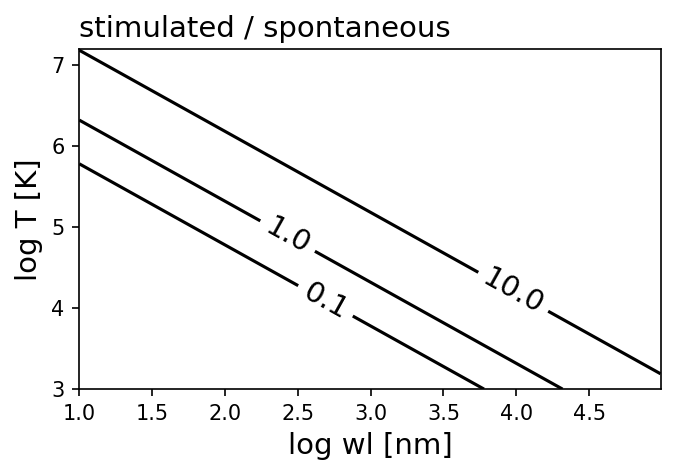

In [4]:
fig, ax = plt.subplots(1,1, figsize=(5,3), dpi=150)
X,Y = np.meshgrid(lwl,lt)
C = plt.contour(X,Y,r,levels=[ 0.1, 1., 10.],colors='black')
C.clabel(fmt='%1.1f', fontsize=14)
ax.set_ylabel("log T [K]", fontsize=14)
ax.set_xlabel("log wl [nm]", fontsize=14)
plt.title('stimulated / spontaneous',loc='left',fontsize=14)

## ■ ionization / recombination  (Miyamoto 1949)

* spontaneous radiative recombination rate  =  $n_{i+1} n_e a_{21}(T,\chi)$

$
\qquad a_{21}(T,\chi) = \frac{2^9 \pi^5}{(6\pi)^{3/2}} \frac{e^{10}}{m^{1/2}c^3h^3} \frac{Z^4}{(kT)^{3/2}} E(\frac{\chi}{kT}), \quad   E(x) = e^x \int_{x}^{\infty}{\frac{e^{-t}}{t}dt}
$
$\quad$ for hydrogen-like ion

$\qquad T$: electron temperature,  $T_r$: radiation temperature


* radiative ionization rate        = $n_i b_{12}(T_r,\chi)$

$
\qquad b_{12}(T_r,\chi)=G(T_r,\chi) a_{21}(T_r,\chi), \quad G(T_r,\chi) \equiv (\frac{2\pi m_e kT_r}{h^2})^{3/2} e^{-\chi/kT_r}
$

* collisional ionization rate        = $n_i n_e \beta_{12}(T,\chi)$

$
\qquad \beta_{12}(T, \chi) = \frac{4 \pi e^4 C_{nl}}{(2 \pi m_e kT)^{1/2} \chi} e^{-\chi/kT}; \quad C_{nl}=0.15 \qquad (H. Bethe)
$

* collisional recombination (tripple collision) rate  = $n_{i+1} n_e^2 \alpha_{21}(T,\chi)$

$
\qquad \alpha_{21}(T, \chi) = \frac {\beta_{12}(T_r,\chi)}{G(T_r,\chi)}
= \frac {h^3}{(2\pi m_e kT_r)^2} \frac{4 \pi e^4 C_{nl}}{\chi}
$



In [60]:
from scipy.integrate import quad

def integrand(t):
    
    return np.exp(-t)/t

def E(x):
    
    return  np.exp(x) * quad(integrand, x, np.inf)[0]


In [72]:
def a21(T,chi,Z):  # spontaneous recomb.coeff., T: electron temp., chi in eV

    a = (2**9 * np.pi**5 * e**10 * Z**4)/((6*np.pi)**1.5 * m_e**0.5 * c**3 * h**3 *(k_B*T)**1.5) *E(chi*ev2erg/k_B/T)
    return a

def G(T,chi):
    
    return (2 * np.pi * m_e * k_B * T)**1.5 / h**3 * np.exp(-chi*ev2erg/k_B/T)

def bet12(T,chi):

    Cnl=0.15
    return (4 * np.pi * e**4 * Cnl)/(2 * np.pi * m_e * k_B * T)**0.5 /(chi * ev2erg) * np.exp(-chi*ev2erg/k_B/T)
    

In [77]:
Te=1E6  # electron temp., K
Tr=6000. # radiation temp.
chi=18.  # eV
Z=20
n_e=1E9
n_i=1E5
print("RR: ",n_i * n_e * a21(Te,chi,Z))
print("RI: ", n_i * G(Tr,chi) * a21(Tr,chi,Z))
print("CI: ", n_i * n_e * bet12(Te,chi))
print("CR: ", n_i * n_e**2 * bet12(Te,chi)/G(Te,chi))
#G(Tr,chi)
(m_e * k_B * Tr)**1.5, h**3, np.exp(-chi*ev2erg/k_B/Tr)

RR:  76322.1730933
RI:  2674.29843259
CI:  317577.907999
CR:  1.62070981106e-10


(2.0729357555734823e-59, 2.909161508158164e-79, 7.5976784150309026e-16)